In [18]:
from google.colab import files
from IPython.display import clear_output
files.upload()
clear_output()

In [57]:
!ls /content

'embeddings (1).jpg'  'lstm1_5 (1).JPG'      'rnn1 (1).png'
 embeddings.jpg        lstm1_5.JPG	      rnn1.png
'gru (1).jpg'	      'lstm (1).jpg'	     'rnn (1).png'
 gru.jpg	       lstm1.png	     'rnn2 (1).png'
'lstm1_1 (1).JPG'     'lstm2 (1).png'	      rnn2.png
 lstm1_1.JPG	       lstm2.png	     'rnn3 (1).png'
'lstm1 (1).png'        lstm.jpg		      rnn3.png
'lstm1_2 (1).JPG'     'lstm_scheme (1).jpg'   rnn.png
 lstm1_2.JPG	      'lstm_scheme (1).png'  'Rnntopos (1).png'
'lstm1_3 (1).JPG'      lstm_scheme.jpg	      Rnntopos.png
 lstm1_3.JPG	       lstm_scheme.png	      sample_data
'lstm1_4 (1).JPG'     'lstm_v2 (1).jpg'
 lstm1_4.JPG	       lstm_v2.jpg


## A recurrent layer in Keras

Humans don’t start their thinking from scratch every second. As you read this document, you understand each word based on your understanding of previous words. You don’t throw everything away and start thinking from scratch again. Your thoughts have persistence.

Traditional neural networks can’t do this, and it seems like a major shortcoming. For example, imagine you want to classify what kind of event is happening at every point in a movie. It’s unclear how a traditional neural network could use its reasoning about previous events in the film to inform later ones.

### RNN

Recurrent neural networks (RNN) address this issue. They are networks with loops in them, allowing information to persist.

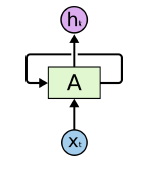

In [19]:
from IPython.display import Image, display
display(Image('rnn1.png'))

In the above diagram, a chunk of neural network, looks at some input and outputs a value. A loop allows
information to be passed from one step of the network to the next.
These loops make recurrent neural networks seem kind of mysterious. However, if you think a bit more, it turns out that they aren’t all that different than a normal neural network.
A recurrent neural network can be thought of as multiple copies of the same network, each passing a message to a successor. Consider what happens if we unroll the loop:

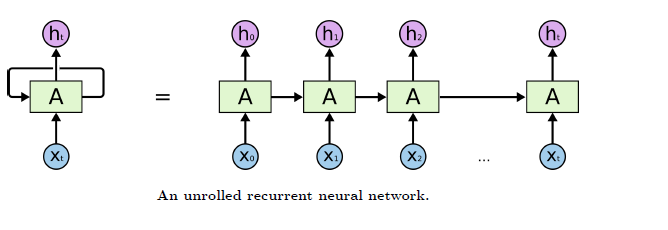

In [20]:
display(Image('rnn2.png'))


This chain-like nature reveals that recurrent neural networks are intimately related to sequences and lists. They’re the natural architecture of neural network to use for such data.
And they certainly are used! In the last few years, there have been incredible success applying RNNs to a variety of problems: speech recognition, language modeling, translation, image captioning...
Currently, recurrent architectures are being replaced by architectures that are based on attention layers, such as transformers.


A recurrent neural network (RNN) processes sequences by iterating through the sequence elements and
maintaining a state containing information relative to what it has seen so far. In effect, an
RNN is a type of neural network that has an internal loop. The state of the
RNN is reset between processing two different, independent sequences (such as two
different IMDB reviews), so you still consider one sequence a single data point: a single
input to the network. **What changes is that this data point is no longer processed in a single step; rather, the network internally loops over sequence elements**.


A recurrent layer has the special property of being able to process sequential input data $[x_1,...,x_n]$.
It consist of a **cell** that updates the **hidden state**, $h_t$ as each element of the sequence $x_t$ is passed through it, one timestep at a time. The hidden state is a vector with length equal to the number of `units` in the cell -it can be thought of a cell's current understanding of the sequence. At timestep $t$ the cell uses the previous value of the hidden state $h_{t-1}$ together with the data from current timestep $x_t$ to produce an updated hidden state vector $h_t$. This recurrent process continues until the end of the sequence. Once the sequence is finished, the layer outputs the final hidden state of the cell, $h_n$, which is then passed on the next layer of the network.


To explain this in more detail, let's unroll the process so that we can see exactly how a single sequence is fed through the layer

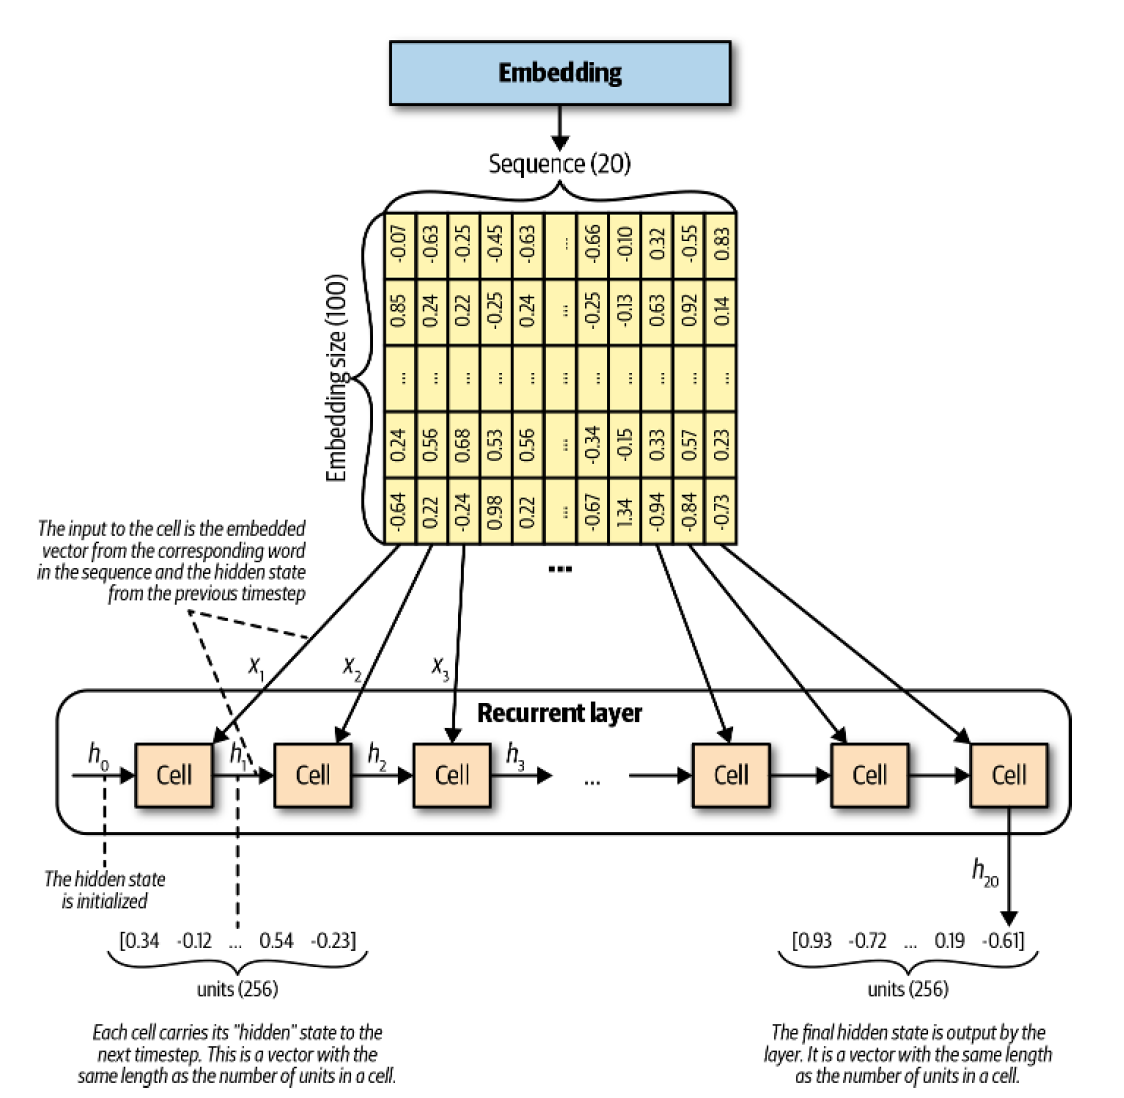

In [21]:
display(Image('rnn.png'))

Here, we represent the recurrent process by drawing a copy of the cell at each timestep and show how the hidden state is constantly being updated as it flows through the cells. We can clearly see how the previous hidden state is blended with the current sequential data point (i.e., the current embedded word vector) to produce the next hidden state. The output from the layer is the final hidden state of the cell. After each word in the input sequence has been processed. It's important to remember that all of the cells in this diagram share the same weights (as they are really the same cell).

The fact that the output from the cell is called hidden state is an unfortunate naming convention. Indeed, the last hidden state is the overall output from the layer, but we can access the hidden state at each individual timestep.

To recap, the size of the hidden state $h_t$ is equal to the number of units in the recurrent layer. This is the parameter that is set when you define the layer and has nothing to do with the length of the sequence. Make sure you do not confuse the term cell with unit. There is one cell in a recurrent layer that is defined by the number of units it contains.

The hidden state \(h_{t}\) at time \(t\) is given by:

$$h_t = \tanh(Wx_t + U h_{t-1} + b)$$

and the output vector \(y_t\) updates by:

$$y_t = h_t$$


here, $h_t$ and $h_{t-1}$ are the hidden states from the time $t$ and $t-1$. $x_t$ is the input at time $t$ and $y_t$ is the output at time $t$. The important thing to notice is that there are two weight matrices $U$ $h\times h$ and $W$ $h\times x$ and one bias term $b$ $h-dim$. Each of these matrices can be thought of as an internal one layer neural network with output size as defined in the parameter units, also bias has the same size. $y_t$ is raw $h_t$ and we don't apply another weight matrix here. This represents one individual cell of RNN, and sequential combination of cells (count equal to time-steps in data) creates the complete RNN layer. Remember the same weight matrices and bias are shared across the RNN cells. Finally, we can compute the number of parameters required to train the RNN layer as follows,

$$(units \times input) + (units \times units) + (units)$$


Each timestep $t$ in the output tensor contains information about
timesteps 1 to t in the input sequence—about the entire past. For this
reason, in many cases, you don’t need this full sequence of outputs; you
just need the last output ($h_t$ at the end of the loop), because it
already contains information about the entire sequence.

In [48]:
max_features = 10000
maxlen = 20
batch_size = 32
from tensorflow.keras.datasets import imdb
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

In [49]:
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

25000 train sequences
25000 test sequences


In [50]:
print('Pad Sequences (samples x time)')

Pad Sequences (samples x time)


In [51]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ajustar la longitud de las secuencias de entrenamiento y prueba
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)


x_train shape: (25000, 20)
x_test shape: (25000, 20)


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Definir el modelo
model = Sequential([
    Embedding(input_dim=max_features, output_dim=32, input_shape=(maxlen,)),
    SimpleRNN(units=28),
    Dense(units=1, activation='sigmoid')
])

# Resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 20, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 28)             │         1,708 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            29 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,737 (1.23 MB)

 Trainable params: 321,737 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6802 - loss: 0.5835 - val_accuracy: 0.7406 - val_loss: 0.5206
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7958 - loss: 0.4428 - val_accuracy: 0.7498 - val_loss: 0.5135
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8370 - loss: 0.3719 - val_accuracy: 0.7484 - val_loss: 0.5194
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8799 - loss: 0.2948 - val_accuracy: 0.7352 - val_loss: 0.5821
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9205 - loss: 0.2136 - val_accuracy: 0.7286 - val_loss: 0.6676
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9516 - loss: 0.1413 - val_accuracy: 0.7154 - val_loss: 0.7705
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9718 - loss: 0.0888 - val_accuracy: 0.7118 - val_loss: 0.8974
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9857 - loss: 0.0508 - val_accuracy: 0.

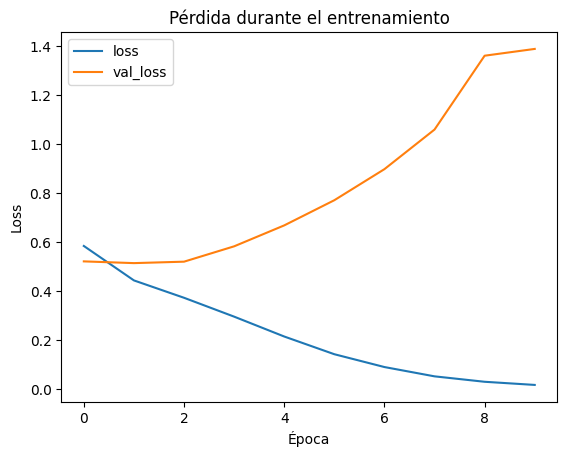

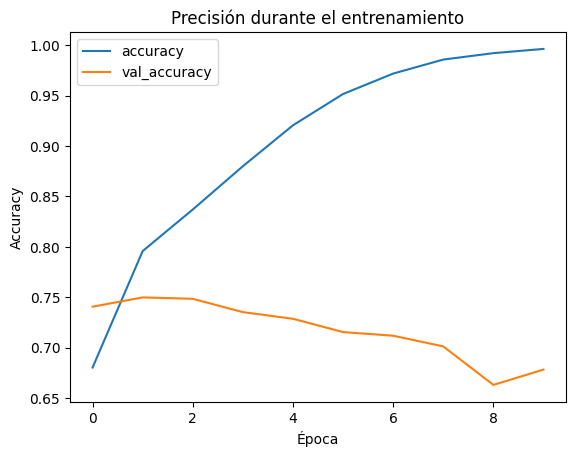

In [54]:
import matplotlib.pyplot as plt
# loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()
#acc
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [55]:
# Inference in text
model.evaluate(x_test,y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6886 - loss: 1.3472


[1.3472224473953247, 0.6886399984359741]

### RNN topologies


The property of being able to work with sequences gives rise to a number of common topologies. We can see the diagram below. In a) we see an example of many-to-may RNN, could be a machine for protein secondary structure prediction, b) could be a machine translation network. c) image captioning network, d) sentiment analysis of sentences.

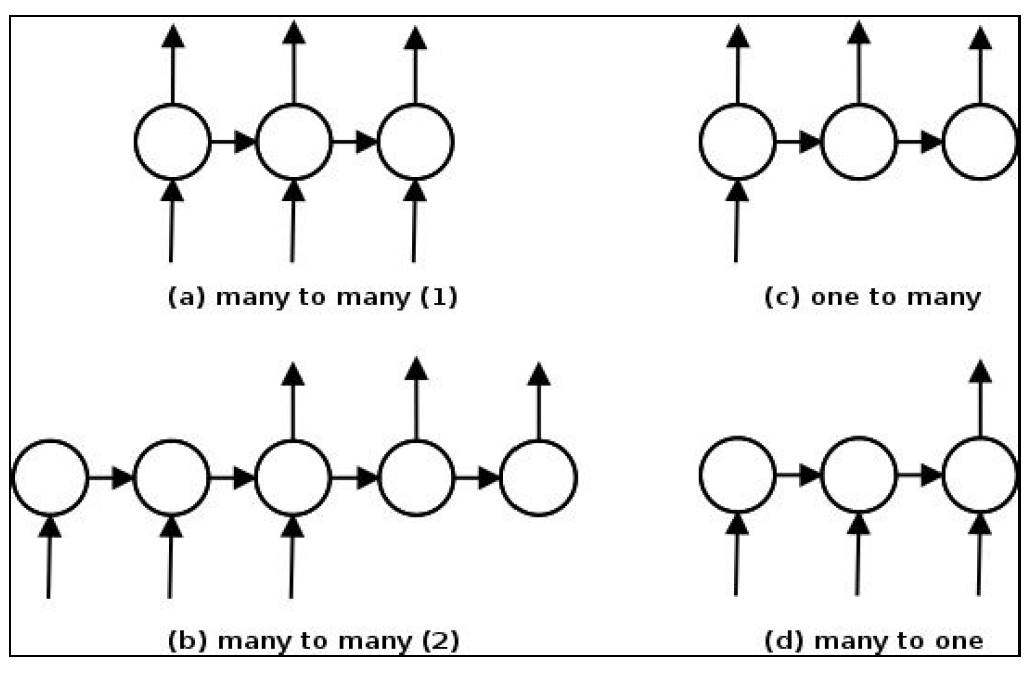

In [58]:
display(Image('Rnntopos.png'))